In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
from evaluation.evaluator import (
    ProtocolCompliance,
    GroundingAndTruthfulness,
    SafetyPolicy,
    ResponseQuality,
    IntegrityHygiene,
    MarathiQuality
)

/Users/adityachhabra/Github/openagrinet/oan-evaluation


Logfire project URL: 
]8;id=284265;https://logfire-us.pydantic.dev/kenpath-aditya/sunbird-va-dev\https://logfire-us.pydantic.dev/kenpath-aditya/sunbird-va-dev]8;;\


In [2]:
categories = {
    'protocol': ProtocolCompliance.model_fields.keys(),
    'grounding': GroundingAndTruthfulness.model_fields.keys(),
    'safety': SafetyPolicy.model_fields.keys(),
    'response': ResponseQuality.model_fields.keys(),
    'integrity': IntegrityHygiene.model_fields.keys(),
    'marathi': MarathiQuality.model_fields.keys()
}

In [3]:
# Set up the data directory
data_dir = Path("data/models")

In [4]:
model_data = {}
model_names = []

for model_dir in data_dir.iterdir():
    if not (model_dir.is_dir() and (eval_file := model_dir / "evaluation.json").exists()):
        continue
    
    model_name = model_dir.name
    model_names.append(model_name)
    
    with open(eval_file, 'r', encoding='utf-8') as f:
        evaluations = json.load(f)
    
    metric_scores = defaultdict(list)
    for item in evaluations:
        if not item or 'evaluation' not in item:
            continue
        
        eval_result = item['evaluation']
        for category, field_names in categories.items():
            if category in eval_result and eval_result[category]:
                for field in field_names:
                    if field in eval_result[category]:
                        value = eval_result[category][field]
                        if isinstance(value, dict) and 'score' in value:
                            metric_key = f"{category}_{field}"
                            if not metric_key.startswith('grounding_'):
                                metric_scores[metric_key].append(value['score'])
    
    model_data[model_name] = {
        metric: np.mean(scores) for metric, scores in metric_scores.items()
    }

all_metrics = sorted(set().union(*(m.keys() for m in model_data.values())))

In [5]:
# Prepare chart data and create visualization
angles = np.linspace(0, 2 * np.pi, len(all_metrics), endpoint=False).tolist()
angles += angles[:1]

clean_labels = [m.split('_', 1)[1].replace('_', ' ').title() if '_' in m else m.replace('_', ' ').title() for m in all_metrics]
for i, label in enumerate(clean_labels):
    words = label.split()
    if len(words) > 3:
        mid = len(words) // 2
        clean_labels[i] = ' '.join(words[:mid]) + '\n' + ' '.join(words[mid:])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
model_colors = colors[:len(model_names)] if len(model_names) <= len(colors) else plt.cm.Set3(np.linspace(0, 1, len(model_names)))

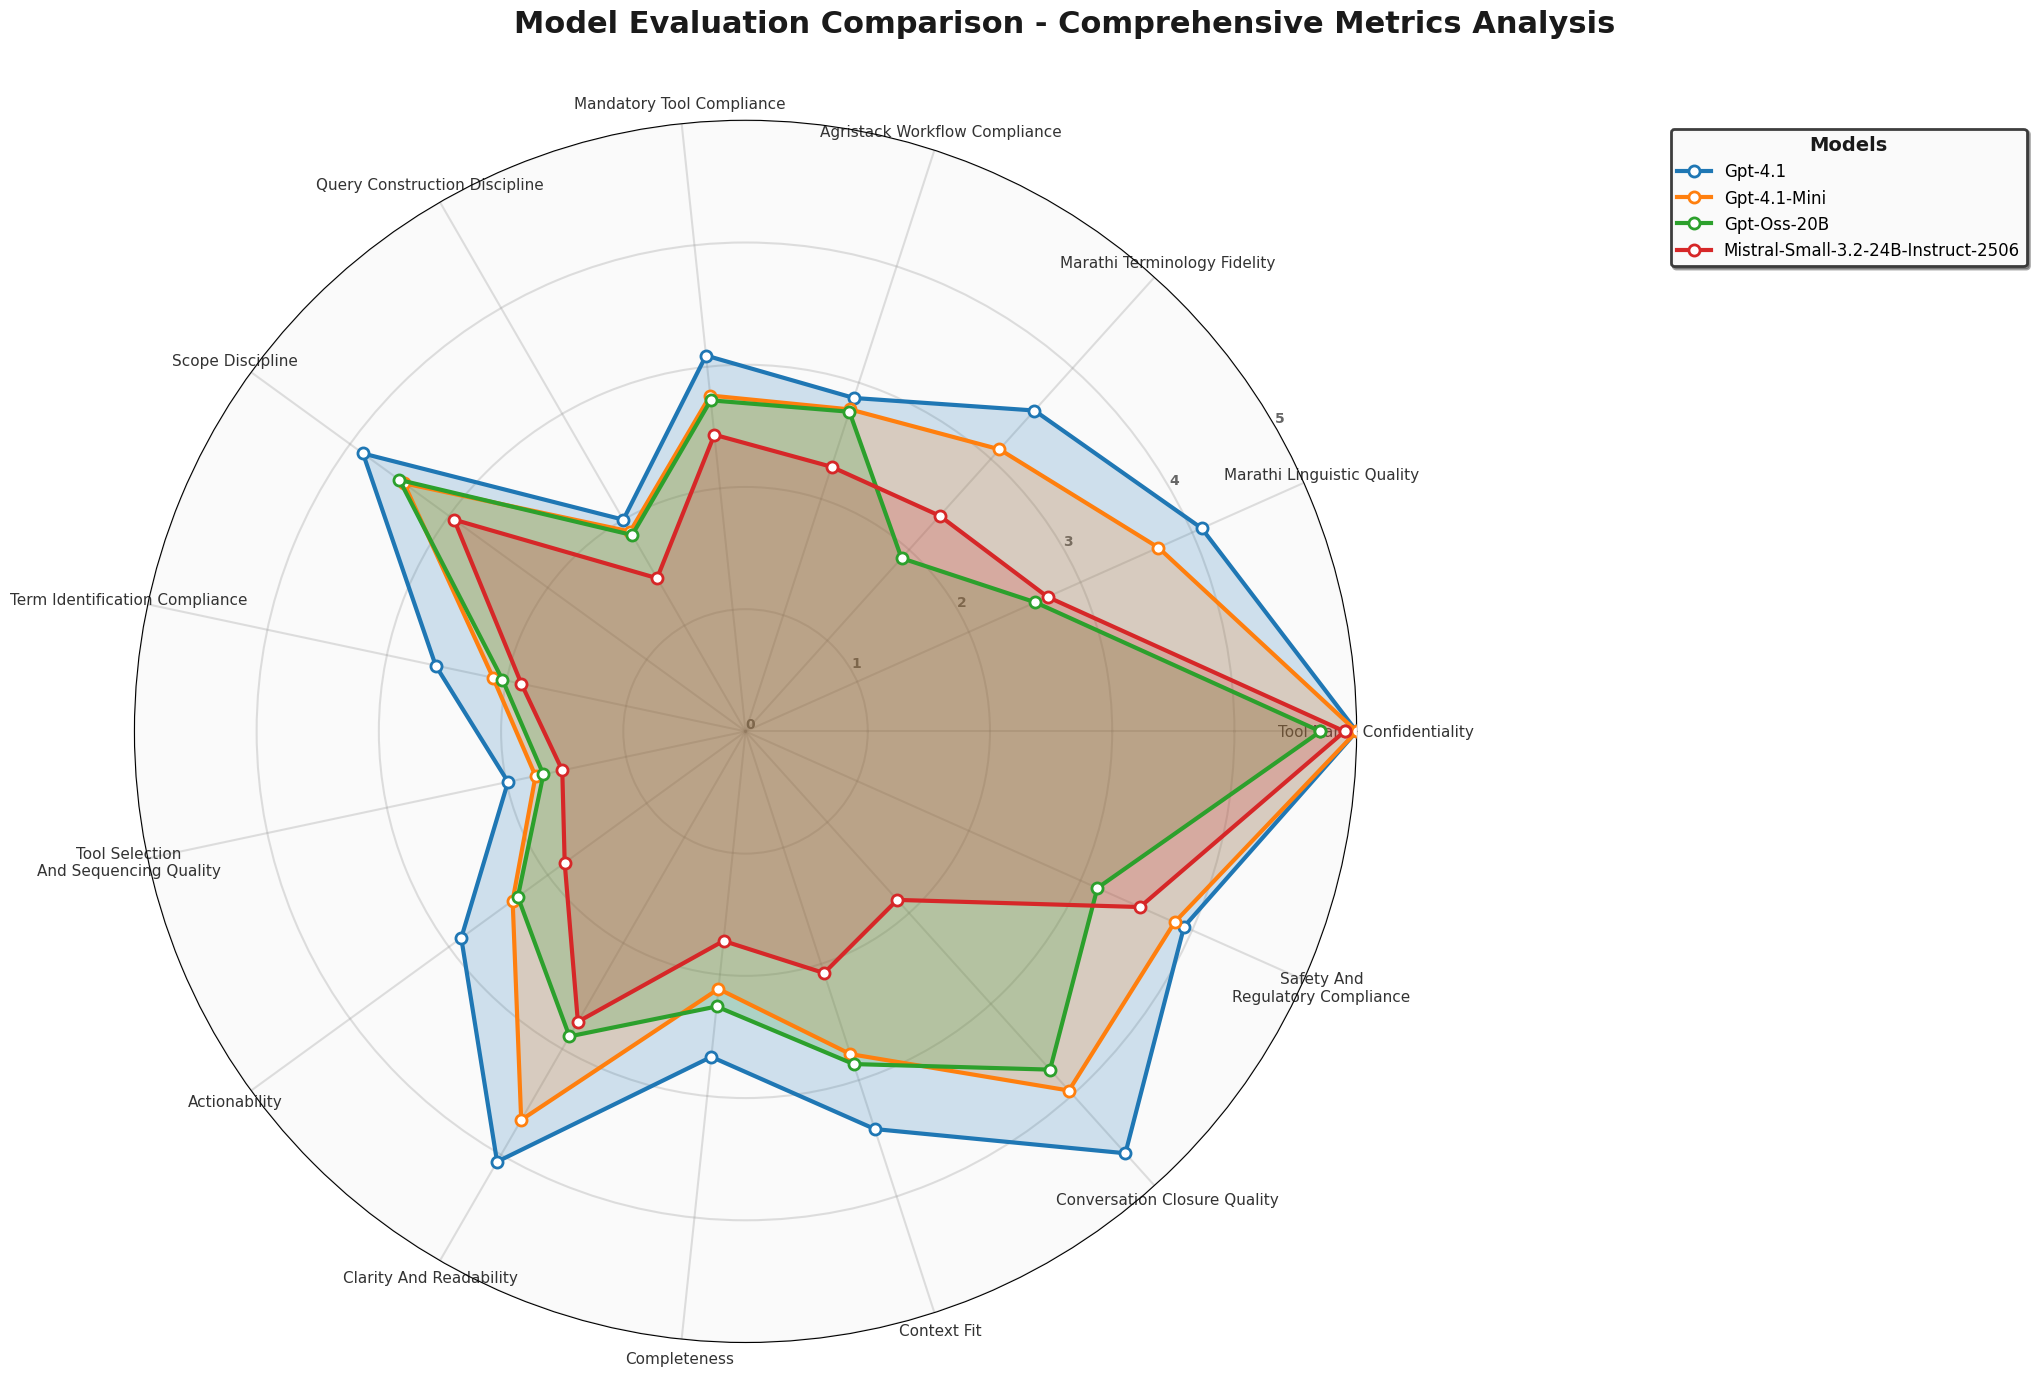

In [6]:
# Create chart
fig, ax = plt.subplots(figsize=(20, 14), subplot_kw=dict(projection='polar'), facecolor='white')
ax.set_facecolor('#fafafa')

for idx, model_name in enumerate(model_names):
    values = [model_data[model_name].get(m, 0) for m in all_metrics] + [model_data[model_name].get(all_metrics[0], 0)]
    display_name = model_name.replace('mistralai_', '').replace('openai_', '').replace('_', ' ').title()
    color = model_colors[idx]
    ax.plot(angles, values, 'o-', linewidth=3, label=display_name, color=color, markersize=8, 
            markerfacecolor='white', markeredgewidth=2, markeredgecolor=color, zorder=3)
    ax.fill(angles, values, alpha=0.2, color=color, zorder=2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(clean_labels, fontsize=11, fontweight='medium', color='#333333', ha='center', va='center')
ax.set_ylim(0, 5)
ax.set_yticks([0, 1, 2, 3, 4, 5])
ax.set_yticklabels(['0', '1', '2', '3', '4', '5'], fontsize=10, fontweight='bold', color='#666666')
ax.grid(True, linestyle='-', linewidth=1.5, alpha=0.3, color='#999999', zorder=1)
ax.set_rlabel_position(30)

fig.suptitle('Model Evaluation Comparison - Comprehensive Metrics Analysis', fontsize=22, fontweight='bold', color='#1a1a1a', y=0.98)

legend = ax.legend(loc='upper left', bbox_to_anchor=(1.25, 1.0), fontsize=12, frameon=True, fancybox=True, 
                   shadow=True, framealpha=0.95, edgecolor='#333333', facecolor='white', title='Models', 
                   title_fontsize=14, ncol=1, columnspacing=1.0, handlelength=2.0, handletextpad=0.8)
legend.get_title().set_fontweight('bold')
legend.get_title().set_color('#1a1a1a')
legend.get_frame().set_linewidth(2)

plt.tight_layout(rect=[0, 0, 0.88, 0.96])
plt.show()
